In [1]:
cd ..

d:\project\ScratchMLP-SingleChar


In [2]:
import numpy as np
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [3]:
transform = transforms.ToTensor()
train_dataset = datasets.EMNIST(root='./data', split='balanced', train=True, download=False, transform=transform)
test_dataset = datasets.EMNIST(root='./data', split='balanced', train=False, download=False, transform=transform)

In [4]:
class_names = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J',
    'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T',
    'U', 'V', 'W', 'X', 'Y', 'Z',
    'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
]

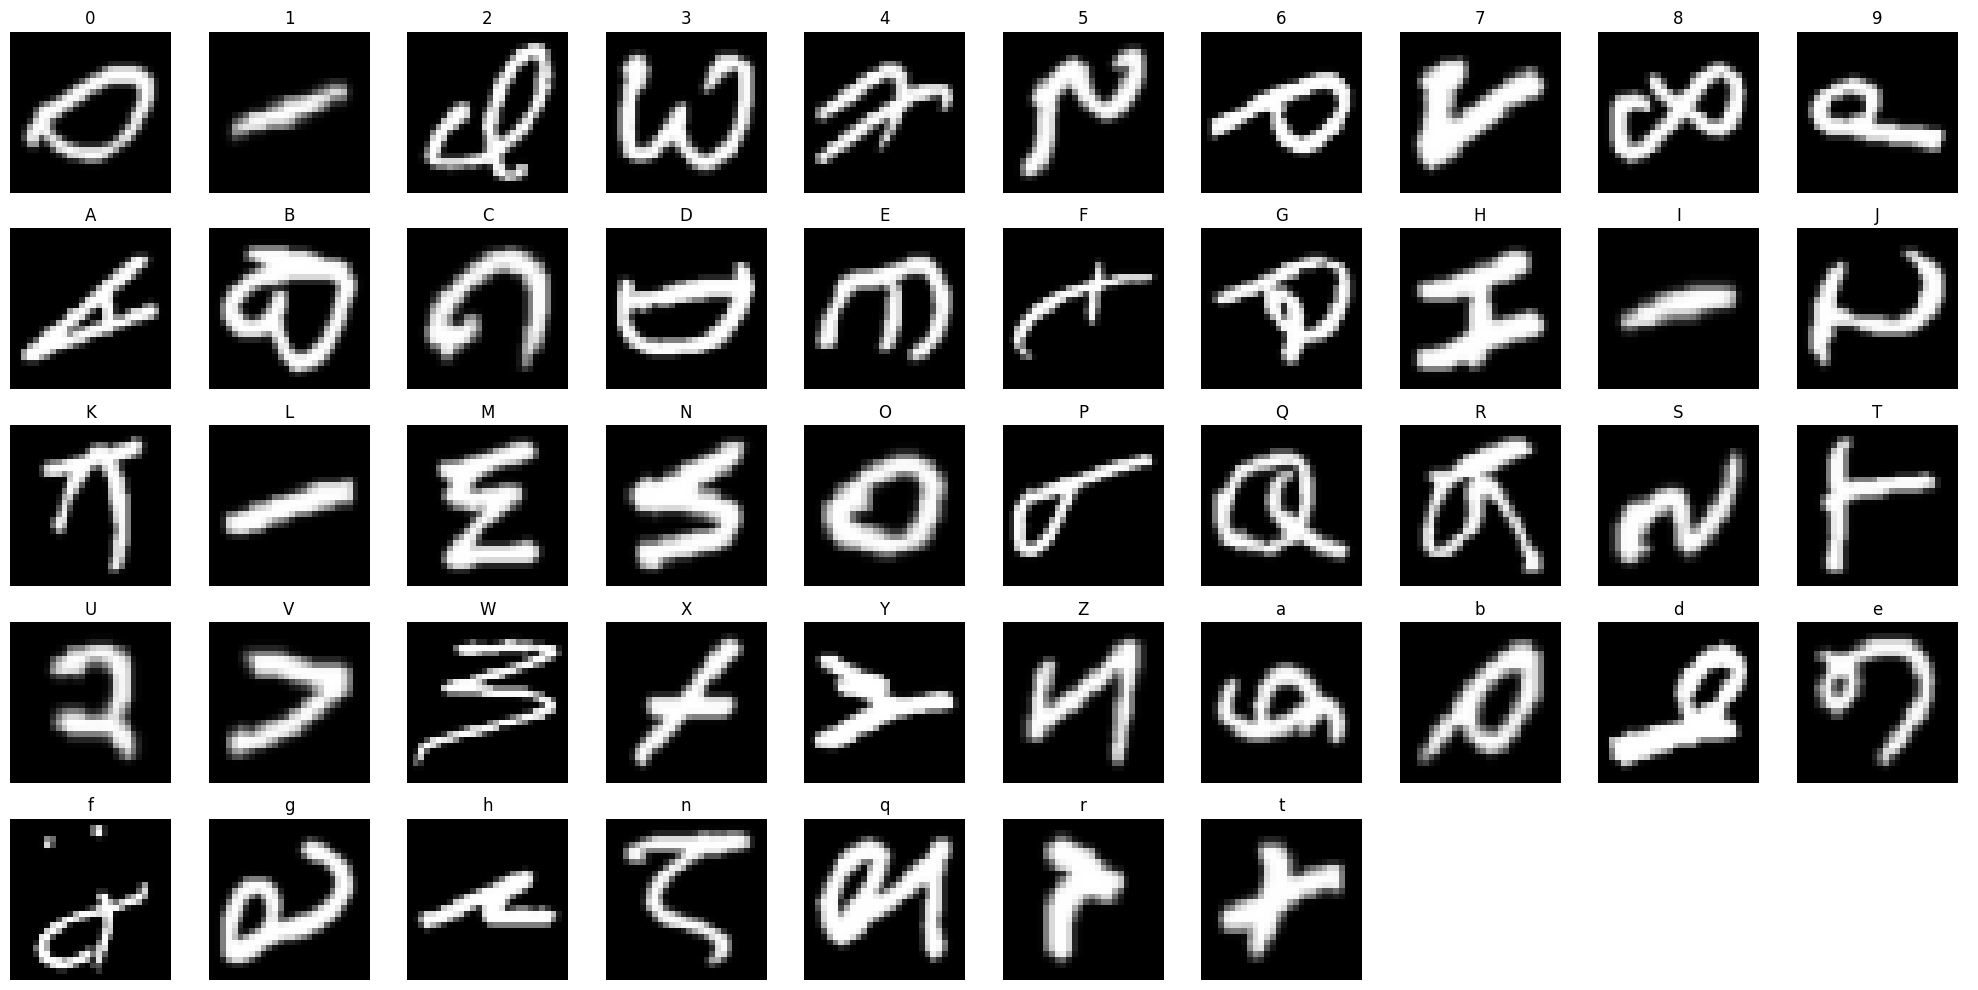

In [5]:
num_classes = len(class_names)

cols = 10
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
axes = axes.flatten()

displayed = [False] * num_classes

for img, label in train_dataset:
    if not displayed[label]:
        axes[label].imshow(img.squeeze().numpy(), cmap='gray')
        axes[label].set_title(class_names[label])
        axes[label].axis('off')
        displayed[label] = True
    if all(displayed):
        break

for j in range(num_classes, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [6]:
X_train = np.array([img.flatten().numpy() for img, _ in train_dataset])
y_train = np.array([label for _, label in train_dataset])
X_test = np.array([img.flatten().numpy() for img, _ in test_dataset])
y_test = np.array([label for _, label in test_dataset])

In [7]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(112800, 784)
(112800,)
(18800, 784)
(18800,)


In [8]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(112800, 784), dtype=float32)

In [9]:
# (n_features, m_examples)

X_train = X_train.T
X_test = X_test.T

In [10]:
print(X_train.shape)
print(X_test.shape)

(784, 112800)
(784, 18800)


In [11]:
y_train

array([45, 36, 43, ..., 23, 31,  8], shape=(112800,))

In [12]:
# (n_classes, m_examples)

Y_train = np.eye(num_classes)[y_train].T
Y_test = np.eye(num_classes)[y_test].T

In [13]:
print(Y_train.shape)
print(Y_test.shape)

(47, 112800)
(47, 18800)
